In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
customers = pd.read_csv('/Volumes/AlexHD/2. Analyst Builder/1. Raw/Statistics Course/files/customers.csv')
orders = pd.read_csv('/Volumes/AlexHD/2. Analyst Builder/1. Raw/Statistics Course/files/orders.csv')
orders['order_date'] = pd.to_datetime(orders['order_date'])

In [2]:
pd.set_option("display.max_rows",None)
orders

,order_id,customer_id,order_date,category,num_items,order_value,shipping_cost,days_to_deliver
0,O000001,C02264,2024-05-11,Clothing,3,96.79,0.00,6
1,O000002,C00283,2024-03-22,Sports,3,139.56,0.00,4
2,O000003,C02621,2024-12-05,Home,2,96.32,0.00,3
3,O000004,C03287,2024-10-22,Clothing,4,153.17,0.00,7
4,O000005,C00172,2024-12-25,Electronics,4,118.65,0.00,3
5,O000006,C03457,2024-04-21,Clothing,1,24.29,12.82,3
6,O000007,C01883,2024-10-29,Sports,4,194.54,0.00,7
7,O000008,C02276,2024-11-01,Electronics,2,54.11,6.98,3
8,O000009,C02622,2024-02-20,Beauty,5,184.96,0.00,4
9,O000010,C00601,2024-10-20,Home,4,190.64,0.00,3


In [9]:
total = len(orders)
total

15000

In [8]:
free_shipping = (orders['shipping_cost'] == 0).sum()

free_shipping

np.int64(9292)

In [11]:
p_free = free_shipping/total

In [12]:
p_free


np.float64(0.6194666666666667)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
orders = pd.read_csv('/Volumes/AlexHD/2. Analyst Builder/1. Raw/Statistics Course/files/orders.csv')
orders['order_date'] = pd.to_datetime(orders['order_date'])
# Count orders per month
monthly = (orders.groupby(orders['order_date'].dt.to_period('M'))
 .size()
 .reset_index(name='orders'))
avg_orders = monthly['orders'].mean()
monthly['month_label'] = monthly['order_date'].astype(str)
print(f'Average monthly orders: {avg_orders:.1f}')
print(monthly)

Average monthly orders: 1250.0
   order_date  orders month_label
0     2024-01    1260     2024-01
1     2024-02    1168     2024-02
2     2024-03    1294     2024-03
3     2024-04    1251     2024-04
4     2024-05    1266     2024-05
5     2024-06    1225     2024-06
6     2024-07    1239     2024-07
7     2024-08    1326     2024-08
8     2024-09    1246     2024-09
9     2024-10    1310     2024-10
10    2024-11    1203     2024-11
11    2024-12    1212     2024-12


In [14]:
# Compare each month to the previous month for sales orders
monthly['prev_orders'] = monthly['orders'].shift(1)
monthly['increased'] = (monthly['orders'] > monthly['prev_orders']).astype(int)
monthly['change'] = monthly['orders'] - monthly['prev_orders']
transitions = monthly.dropna()
p_increase = transitions['increased'].mean()
n_up = transitions['increased'].sum()
print(f'Months where orders increased: {int(n_up)} out of {len(transitions)}')
print(f'P(next month > this month) = {p_increase:.3f}')

Months where orders increased: 6 out of 11
P(next month > this month) = 0.545


In [15]:
# Was the current month above or below the yearly average?

transitions = transitions.copy()
transitions['above_avg'] = (transitions['prev_orders'] > avg_orders).astype(int)
above = transitions[transitions['above_avg'] == 1]
below = transitions[transitions['above_avg'] == 0]
p_inc_given_above = above['increased'].mean()
p_inc_given_below = below['increased'].mean()

print(f'P(increase | this month ABOVE average) = {p_inc_given_above:.3f}')
print(f'P(increase | this month BELOW average) = {p_inc_given_below:.3f}')

P(increase | this month ABOVE average) = 0.167
P(increase | this month BELOW average) = 1.000


In [16]:
avg_orders

np.float64(1250.0)

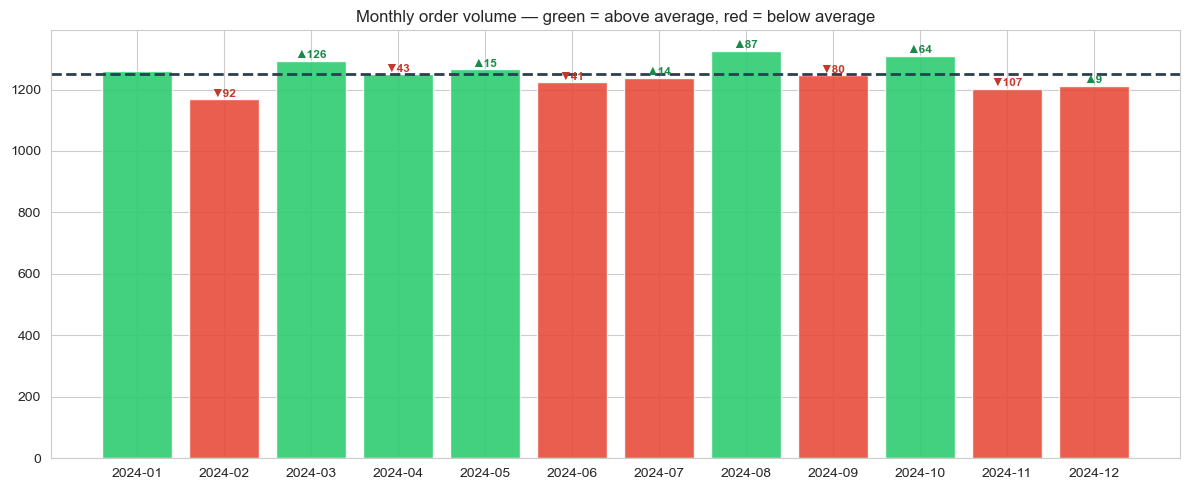

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#E74C3C' if v < avg_orders else '#2ECC71'
 for v in monthly['orders']]
ax.bar(monthly['month_label'], monthly['orders'],
 color=bar_colors, edgecolor='white', alpha=0.9)
ax.axhline(avg_orders, color='#2C3E50', linewidth=2, linestyle='--',
 label=f'Average ({avg_orders:.0f} orders)')
# Annotate each bar with the month-over-month change
for i, row in transitions.iterrows():
 arrow = '▲' if row['change'] > 0 else '▼'
 color = '#1A8A4A' if row['change'] > 0 else '#C0392B'
 ax.text(i, monthly.loc[i,'orders'] + 8,
 f'{arrow}{abs(int(row["change"]))}',
 ha='center', fontsize=8.5, fontweight='bold', color=color)
ax.set_title('Monthly order volume — green = above average, red = below average')
plt.tight_layout()
plt.show()

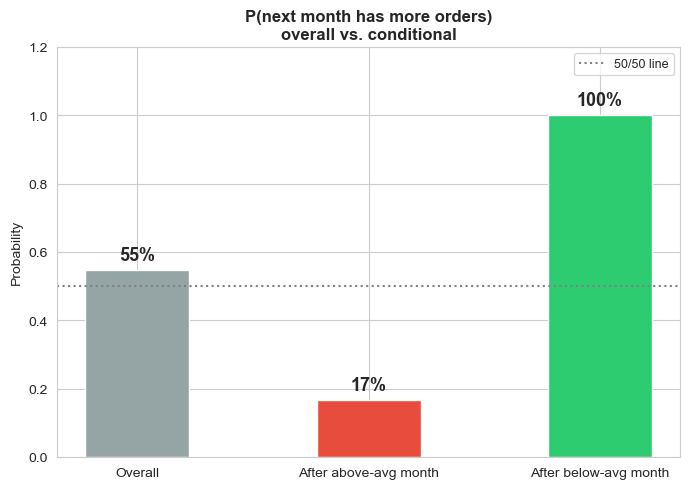

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Overall', 'After above-avg month', 'After below-avg month']
probs  = [p_increase, p_inc_given_above, p_inc_given_below]
colors = ['#95A5A6', '#E74C3C', '#2ECC71']
bars = ax.bar(labels, probs, color=colors, edgecolor='white', width=0.45)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='50/50 line')
ax.set_title('P(next month has more orders)\noverall vs. conditional', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability')
ax.set_ylim(0, 1.2)
for bar, val in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.03,
            f'{val:.0%}', ha='center', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()